### **4. Técnicas de Redução da Dimensionalidade: Escalonamento Multidimensional (MDS)** 

#### Autor: Tony Esaú de Oliveira.

##### Universidade Federal do Cariri


#### **Maldição da Dimensionalidade**

A maldição da dimensionalidade refere-se às severas dificuldades que surgem quando se trabalha com espaços que possuem muitas dimensões. À medida que a dimensionalidade ($D$) é aumentada, o número de regiões em uma grade regular cresce exponencialmente, tornando-se impraticável preencher esses espaços com dados suficientes para análises estatísticas. Geometricamente, as intuições desenvolvidas em três dimensões falham em espaços dimensionais superiores; por exemplo, em altas dimensões, a maior parte do volume de uma esfera concentra-se em uma casca fina perto de sua superfície e a massa de uma distribuição Gaussiana concentra-se em um anel fino a uma certa distância da origem.

#### **Redução de Dimensionalidade**

A redução de dimensionalidade é o processo de alterar a representação de dados complexos, originalmente descritos por um grande número de variáveis, para uma descrição de baixa dimensão usando apenas um pequeno número de parâmetros livres. Essa técnica pode ser implementada por meio de duas abordagens principais:

- **Seleção de atributos:** Identifica e seleciona o menor subconjunto de variáveis originais que melhor representam as características essenciais do problema, descartando as irrelevantes ou redundantes;
- **Extração de atributos:** Realiza transformações matemáticas ou combinações das variáveis originais para criar novas representações (como no método PCA), mantendo o máximo de informação possível em um número menor de dimensões.

A importância da redução de dimensionalidade reside em diversos fatores práticos e teóricos:

- **Eficiência Computacional e de Armazenamento:** Com a geração exponencial de dados (*Big Data*), a redução diminui a necessidade de espaço em disco e acelera drasticamente o tempo de processamento dos algoritmos;
- **Melhoria de Desempenho:** Ao eliminar redundâncias e ruídos ("informações irrelevantes"), as técnicas ajudam a evitar o sobreajuste (*overfitting*), permitindo que modelos de aprendizado de máquina alcancem maior precisão e generalização;
- **Visualização de Dados:** Projetar dados de alta dimensão em espaços de duas ou três dimensões permite que humanos visualizem estruturas, agrupamentos e padrões ocultos de forma intuitiva;
- **Estrutura Intrínseca:** Dados reais frequentemente residem em variedades não lineares (*manifolds*) de baixa dimensão embutidas no espaço de alta dimensão; a redução permite explorar essa estrutura efetiva inferior.

---

#### **Human Activity Recognition with Smartphones**

##### **Visão Geral**
- Classificação de atividades humanas (andar, sentar, etc.);
- ~3.000 amostras;
- 561 features;
- Dados de sensores de smartphone (acelerômetro e giroscópio).

##### **Origem dos Dados**
Sensores usados:
- Acelerômetro: movimento linear;
- Giroscópio: rotação.

Obs.: Celular posicionado na cintura dos usuários.

##### **Estrutura das Features**

Formato geral:

[t/f][Body/Gravity][Acc/Gyro]-[estatística]-[eixo]

##### **Componentes**

- **t / f**  
  - `t`: domínio do tempo;
  - `f`: domínio da frequência.

- **Tipo de sinal**  
  - `BodyAcc`: aceleração do corpo; 
  - `GravityAcc`: gravidade;
  - `BodyGyro`: rotação.

- **Estatísticas**  
  - `mean()`: média;
  - `std()`: desvio padrão; 
  - `energy()`: energia;
  - `entropy()`: entropia. 

- **Eixos**  
  - `X`, `Y`, `Z`


##### **Exemplo**

- `tBodyAcc-mean()-X`: média da aceleração no eixo X;  
- `fBodyGyro-energy()-Z`: energia do giroscópio no eixo Z.

##### Intuição

- Cada linha: um intervalo de movimento;
- Cada coluna: uma característica desse movimento. 

---

#### **Escalonamento Multidimensional**

O Escalonamento Multidimensional (MDS) é uma técnica de redução de dimensionalidade e análise de dados que busca encontrar uma representação de objetos em um espaço de baixa dimensão (geralmente euclidiano) de modo que as distâncias entre os pontos nesse novo espaço correspondam, o mais fielmente possível, às dissimilaridades ou distâncias originais entre os objetos. Formalmente, dado um conjunto de $n$ objetos com dissimilaridades observadas $\{\delta_{rs}​\}$ medidas entre todos os pares, o MDS busca uma configuração de $n$ pontos em um espaço de dimensão $p$ (onde $p<n$). Cada ponto $x_r$​ representa o objeto $r$, e o objetivo é que as distâncias $d_{rs}$​ entre os pontos no espaço projetado "casem" com as dissimilaridades originais $\delta{rs}​.$ Existem duas categorias principais:

- **MDS Métrico**: Trata as dissimilaridades como dados quantitativos. Inclui o Escalonamento Clássico (preserva distâncias euclidianas diretamente) e o MDS de Mínimos Quadrados (minimiza uma função de perda entre distâncias e dissimilaridades transformadas);
- **MDS Não-Métrico**: Utilizado quando apenas a ordem de classificação (rank) das dissimilaridades é conhecida ou deve ser preservada, não seus valores exatos.

A aplicação do MDS clássico (também conhecido como Análise de Coordenadas Principais) segue estas etapas matemáticas fundamentais:

1. **Obtenção das Dissimilaridades**: Constrói-se uma matriz de dissimilaridade $\{\delta_{rs}​\}$ entre todos os objetos do conjunto de dados;
2. **Transformação da Matriz**: Cria-se uma matriz $A$ cujos elementos são dados por $a_{rs}​=−\frac{1}{2}​\delta_{rs}^2$​;
3. **Centralização Dupla**: Aplica-se a centralização dupla na matriz $A$ para obter a matriz $B$ (matriz de produto escalar). Isso garante que o centroide da nova configuração de pontos esteja na origem, eliminando indeterminações de translação;
4. **Decomposição Espectral**: Calcula-se os autovalores ($\lambda$) e autovetores ($v$) da matriz $B$;
5. **Seleção da Dimensão ($p$)**: Escolhe-se o número de dimensões desejado (geralmente $2$ ou $3$ para visualização). Se muitos autovalores forem pequenos, eles podem ser negligenciados sem grande perda de informação;
6. **Cálculo das Coordenadas**: As coordenadas dos pontos no novo espaço euclidiano são calculadas a partir dos autovalores e autovetores selecionados $(x_{ri} ​= \lambda_i^{\frac{1}{2}}​v_{ir}​)$.

---

In [2]:
import pandas as pd 
import numpy as np

In [3]:
dados = pd.read_csv('Conjunto_Dados/Human_Activity_Recognition_with_Smartphones.csv')

In [4]:
dados.head(10)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,STANDING
5,0.279220,-0.018620,-0.113902,-0.994455,-0.970417,-0.965316,-0.994585,-0.969481,-0.965897,-0.937856,...,-0.857565,-0.095681,0.048849,0.760684,-0.072216,-0.689816,0.294896,-0.068471,2,STANDING
6,0.279746,-0.018271,-0.104000,-0.995819,-0.976354,-0.977725,-0.995996,-0.973665,-0.979253,-0.937856,...,-0.391286,-0.309083,-0.000857,0.728514,-0.333771,-0.690085,0.295282,-0.067065,2,STANDING
7,0.274601,-0.025035,-0.116831,-0.995594,-0.982069,-0.985262,-0.995341,-0.981485,-0.984610,-0.941263,...,-0.672358,-0.025526,-0.214033,0.437640,-0.366674,-0.688785,0.295981,-0.067706,2,STANDING
8,0.272529,-0.020954,-0.114472,-0.996784,-0.975906,-0.986597,-0.997029,-0.973735,-0.985556,-0.941263,...,-0.853248,0.144626,-0.035564,-0.181800,0.087320,-0.685390,0.299394,-0.065491,2,STANDING
9,0.275746,-0.010372,-0.099776,-0.998373,-0.986933,-0.991022,-0.998663,-0.987140,-0.991084,-0.943761,...,-0.741435,0.157584,-0.033487,-0.350893,0.343146,-0.684110,0.300822,-0.064263,2,STANDING


In [5]:
dados.shape

(2947, 563)

In [6]:
dados['Activity'].unique()

mapa = {
    'STANDING': 0,
    'SITTING': 1,
    'WALKING_DOWNSTAIRS': 2,
    'LAYING': 3,
    'WALKING': 4,
    'WALKING_UPSTAIRS': 5
}

dados['Activity'] = dados['Activity'].map(mapa)

---

In [7]:
from sklearn.preprocessing import StandardScaler

# Separação entre variáveis independentes (X) e variável dependente (y).
X = dados.drop('Activity', axis=1)
y = dados['Activity']

# Padronização dos dados.
X_scaled = StandardScaler().fit_transform(X)

O MDS reduz a dimensão para duas colunas, de modo que:

- Cada ponto vira um vetor em baixa dimensão ($k \ll d$);
- Distâncias no novo espaço tentam aproximar as originais;
- Resultado: um **embedding geométrico**;
- Pode ser usado para visualização, clustering ou como *feature input* (entrada para modelo).

In [ ]:
from sklearn.manifold import MDS

# Configuração do MDS para redução para 2 componentes.
mds = MDS(
    n_components=2, # Pode ser ajustado para 3 ou mais componentes, se desejado.
    metric=True,  # MDS métrico (usa distâncias euclidianas).
    n_init=4,
    max_iter=300,
    random_state=42,
    n_jobs=-1
)

# Aplicação do MDS para reduzir a dimensionalidade dos dados.
X_mds = mds.fit_transform(X_scaled)

print(X_mds.shape)

(2947, 2)


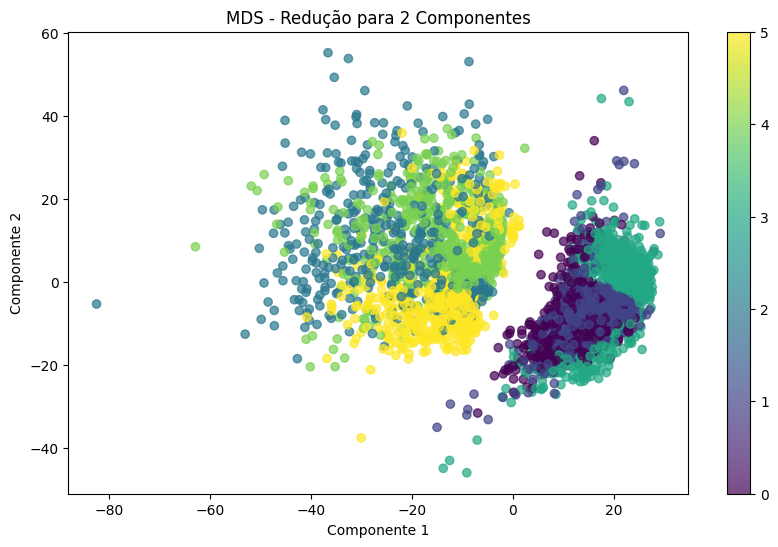

In [ ]:
# Plotagem dos dados reduzidos.
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# O parâmetro 'c=y' colore os pontos de acordo com as classes (atividades).
scatter = plt.scatter(X_mds[:, 0], X_mds[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.title('MDS - Redução para 2 Componentes')   
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.colorbar(scatter)
plt.show()

#### **MDS: Utilidade Prática**

**Quando usar:**

- Quando você tem uma **matriz de distâncias/dissimilaridade**;
- Quando quer **visualizar dados em 2D ou 3D preservando relações geométricas**;
- Quando não há features confiáveis, apenas relações entre amostras.

**Quando não usar:**
- Dataset grande (custo $O(n^2)$);
- Quando o objetivo é **modelo preditivo**;
- Quando já existem features vetoriais boas (use PCA/SVD);
- Quando a métrica de distância não é confiável.

**Vantagens**:
- Preserva relações de distância;
- Bom para visualização e exploração;
- Não exige suposição linear.

**Desvantagens**:
- Alto custo computacional;
- Sensível à métrica de distância;
- Não supervisionado;
- Pouco escalável.